# Evaluation of the results

In [1]:
from pathlib import Path
import json
import pandas as pd
from python_tex_tools import TexExporter, plot_context_manager
import hashlib

In [ ]:
# baselines
jerry_3dbp= Path("/home/blei/BagBuddy/evaluation/c_evaluator/experiment_output/jerry_3dbp")
wadaboa_bl = Path("/home/blei/BagBuddy/evaluation/c_evaluator/experiment_output/wadaboa_bl")
wadaboa_mr = Path("/home/blei/BagBuddy/evaluation/c_evaluator/experiment_output/wadaboa_mr")
wadaboa_cg = Path("/home/blei/BagBuddy/evaluation/c_evaluator/experiment_output/wadaboa_cg")
gopt = Path("/home/blei/BagBuddy/evaluation/c_evaluator/experiment_output/gopt")
llm_pack_gpt_5 = Path("/home/blei/BagBuddy/experiment_output/llm_pack_gpt-5")
llm_pack_gpt_5_mini = Path("/home/blei/BagBuddy/experiment_output/llm_pack_gpt-5-mini")
llm_pack_claude_4 = Path("/home/blei/BagBuddy/experiment_output/llm_pack_claude-sonnet-4-20250514")
llm_pack_gemini_3_flash = Path("/home/blei/BagBuddy/experiment_output/llm_pack_gemini-3-flash-preview")
llm_pack_scaling = Path("/home/blei/BagBuddy/experiment_output/llm_pack_gpt-5-mini_scaling")
vanilla_llm_pack = Path("/home/blei/BagBuddy/experiment_output/vanilla_llm_pack")

llm_pack_hw_constrained = Path("/home/blei/BagBuddy/experiment_output/llm_pack_gpt-5-mini_hw_pure_binary_constraints") # only binary constraints, with collision padding
llm_pack_hw_base_level_constraints = Path("/home/blei/BagBuddy/experiment_output/llm_pack_gpt-5-mini_hw") # binary with base level constraint, no stability


: 

: 

In [ ]:
reference_md5 = None
def load_exp(path: Path):
    # find all experiment_results.json files in subdirectories
    results_files = list(path.rglob("experiment_results.json"))
    all_results = []
    results_files.sort(key=lambda p: int(p.parent.name))
    for i, result_file in enumerate(results_files):
        json_data = json.loads(result_file.read_text())
        all_results.append(json_data[-1])

    all_results = pd.DataFrame(all_results)
    grocery_md5 = hashlib.md5(all_results["grocery_items"].to_list().__str__().encode()).hexdigest()
    global reference_md5
    if reference_md5 is not None:
        if str(grocery_md5) != str(reference_md5):
            print(f"Grocery MD5 has changed! Previous: {reference_md5}, New: {grocery_md5}")
    else: 
        reference_md5 = grocery_md5

    try: 
        all_results = all_results[["density", "c_score", "n_violations","n_total" , "packing_time"]]
    except KeyError:
        all_results = all_results[["density", "c_score"]]
    return all_results

: 

: 

## Jerry

In [ ]:
jerry_res = load_exp(jerry_3dbp)
jerry_res.head()

,density,c_score,n_violations,n_total,packing_time
0,0.173324,-2.639057,1,1,0.173758
1,0.252387,-3.167901,2,2,0.164894
2,0.270062,-1.131020,1,2,0.173707
3,0.216573,-4.022168,2,6,0.174892
4,0.132213,0.000000,0,0,0.173002


: 

: 

## Wadaboa

### Baseline

In [ ]:
wadaboa_bl_res = load_exp(wadaboa_bl)

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 3b8149e22489dc9aee2ee5b877edb5fa


: 

: 

### Wadaboa MR

In [ ]:
wadaboa_mr_res = load_exp(wadaboa_mr)
wadaboa_mr_res.head()

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 7a916317011d2d8647417a7e0df3a43a


,density,c_score,n_violations,n_total,packing_time
0,0.267151,-1.836095,1,2,0.208823
1,0.145553,0.000000,0,0,0.167979
2,0.190443,-2.233592,1,1,0.171655
3,0.127779,0.000000,0,0,0.171019
4,0.139509,0.000000,0,0,0.168494


: 

: 

## wadaboa cg

In [ ]:
wadaboa_cg_res = load_exp(wadaboa_cg)
wadaboa_cg_res.head()

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 820052794e10f37bca7c6ab6c371d9c5


,density,c_score,n_violations,n_total,packing_time
0,0.173861,0.000000,0,0,1325.731514
1,0.136764,-0.843917,0,4,1206.701444
2,0.238708,-0.934309,1,1,939.963007
3,0.141106,0.000000,0,0,0.479667
4,0.208334,-4.361824,2,3,3125.971330


: 

: 

## GOPT

In [ ]:
gopt_res = load_exp(gopt)
gopt_res.head()

,density,c_score,n_violations,n_total,packing_time
0,0.251838,-2.352517,1,8,0.367895
1,0.255405,-1.624891,0,7,0.353727
2,0.201449,-5.912499,3,8,0.357832
3,0.304918,-2.032883,1,10,0.359443
4,0.247483,-2.031068,0,4,0.352672


: 

: 

## LLM-Pack

In [ ]:
llm_pack_gpt_5 = load_exp(llm_pack_gpt_5)
llm_pack_gpt_5.head()

,density,c_score,n_violations,n_total,packing_time
0,0.484816,-0.146843,0,3,13.333089
1,0.475845,-2.650768,1,5,13.802497
2,0.427013,-0.074108,0,1,8.979442
3,0.354834,-0.384147,0,3,44.828553
4,0.454804,-1.000737,0,6,14.742459


: 

: 

In [ ]:
llm_pack_gpt_5_mini = load_exp(llm_pack_gpt_5_mini)
llm_pack_gpt_5_mini

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: aa2c7d462c0f8de247a5e285d747226d


,density,c_score,n_violations,n_total,packing_time
0,0.512264,-0.360417,0,4,58.209906
1,0.475845,-1.037104,0,8,35.410987
2,0.427013,-0.113329,0,1,35.227272
3,0.354834,-0.387229,0,4,34.751030
4,0.512264,-0.360417,0,4,34.850207
5,0.475845,-1.037104,0,8,7.873115
6,0.427013,-0.113329,0,1,10.958102
7,0.354834,-0.387229,0,4,37.167269
8,0.454804,-1.000737,0,6,13.439126
9,0.388730,-0.954692,0,4,26.967344


: 

: 

In [ ]:
llm_pack_claude_4 = load_exp(llm_pack_claude_4)
llm_pack_claude_4.head()

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 78a41a13dba855823ded1172b4f549b5


,density,c_score,n_violations,n_total,packing_time
0,0.412115,-0.806476,0,2,34.339722
1,0.473074,-2.614886,1,5,34.416121
2,0.412115,-0.806476,0,2,34.344783
3,0.473074,-2.614886,1,5,34.412720
4,0.341088,-0.693147,0,1,7.952466


: 

: 

In [ ]:
llm_pack_gemini_3_flash = load_exp(llm_pack_gemini_3_flash)
llm_pack_gemini_3_flash.head()

,density,c_score,n_violations,n_total,packing_time
0,0.484816,-0.146843,0,3,12.620373
1,0.475845,-2.650768,1,5,10.870766
2,0.427013,-0.113329,0,1,16.267576
3,0.354834,-2.164599,1,3,36.022950
4,0.454804,-1.000737,0,6,14.784051


: 

: 

### HW-Constrained LLM-Pack:

In [ ]:
llm_pack_hw_constrained_ = load_exp(llm_pack_hw_constrained)
llm_pack_hw_constrained_.mean().transpose()

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 6af53fb7cf18bbf3be0bc47eb4f134c8


density          0.219261
c_score         -1.791723
n_violations     0.600000
n_total          4.300000
packing_time    15.822809
dtype: float64

: 

: 

### Sensitivity: 

### Vanilla LLM-Pack (Ablation)

In [ ]:
vanilla_llm_pack = load_exp(vanilla_llm_pack)
vanilla_llm_pack

,density,c_score,n_violations,n_total,packing_time
0,0.557527,-1.518742,0,5,25.380121
1,0.571448,-5.555644,3,5,22.373374
2,0.427013,-0.074108,0,1,10.396931
3,0.369465,-0.835463,0,2,34.572388
4,0.497536,-1.765237,0,5,34.299670
5,0.508002,-2.072722,0,5,31.591152
6,0.299027,-0.287682,0,1,34.238927
7,0.428527,-0.894153,0,7,34.596538
8,0.548718,-2.502922,1,6,17.399742
9,0.575517,-1.651124,0,4,8.915555


: 

: 

## Final (big) table: - effort matters!!

In [ ]:
exporter = TexExporter()

: 

: 

In [ ]:
from IPython.display import display

print("Baseline Comparison:")
baseline_df = pd.concat([jerry_res.mean(), wadaboa_bl_res.mean(), wadaboa_mr_res.mean(), wadaboa_cg_res.mean(), gopt_res.mean(), llm_pack_gpt_5_mini.mean(), vanilla_llm_pack.mean()], axis=1, keys=["jerry", "wadaboa_bl", "wadaboa_mr", "wadaboa_cg", "GOPT", "llm_pack", "vanilla_llm_pack"]).transpose().round(3)
display(baseline_df)

# keep only the desired metrics, in strict order
baseline_df_copy = baseline_df.loc[["jerry","GOPT","wadaboa_cg","llm_pack","vanilla_llm_pack"], ["density", "n_violations", "n_total","packing_time"]].copy()

# rename column for LaTeX macro \metricName
metric_pretty_names = {"density":"Density", "n_violations": "$a\\metricName$~", "packing_time": "Time [s]", "n_total": "$N_{o}$"}
baseline_df_copy.rename(columns=metric_pretty_names, inplace=True)
baseline_df_copy.rename(index={"jerry":r"Dube et~al. \cite{dube2006}", "wadaboa_bl":"Wadaboa-BL", "wadaboa_mr":"Wadaboa-MR", "wadaboa_cg":r"Elhedhli et~al. \cite{elhedhli2019}", "GOPT":"GOPT", "llm_pack":"LLM-Pack", "vanilla_llm_pack":"LLM-Pack (vanilla)", "GOPT":r"GOPT \cite{Xiong_2024}"}, inplace=True)

bf_default_options = {
    "axis": 0,  # 0 best in columns, 1 best in rows
    "higher_or_lower_is_better": ["higher", "lower", "lower","lower"],
}
exporter.add_table("baseline", baseline_df_copy, bf_options=bf_default_options)

print("LLM-Pack ablation:")
ablation_df = pd.concat([llm_pack_gpt_5_mini.mean(), vanilla_llm_pack.mean()], axis=1, keys=["llm_pack", "vanilla_llm_pack"]).transpose().round(3)
display(ablation_df)
ablation_df_copy = ablation_df.loc[:, ["density", "n_violations", "n_total", "packing_time"]].copy()
exporter.add_table("ablation", ablation_df_copy, bf_options=bf_default_options)

print("LLM-VLM sensitivity study:")
ss_df = pd.concat([llm_pack_gpt_5.mean(), llm_pack_gpt_5_mini.mean(), llm_pack_claude_4.mean(), llm_pack_gemini_3_flash.mean()], axis=1, keys=["GPT-5", "GPT-5-mini", "Claude Sonnet 4", "Gemini 3 Flash"]).transpose().round(3)
display(ss_df)
ss_df_copy = ss_df.loc[:, ["density", "n_violations", "n_total", "packing_time"]].copy()
ss_df_copy.rename(columns=metric_pretty_names, inplace=True)
exporter.add_table("sensitivityStudy", ss_df_copy, bf_options=bf_default_options)


Baseline Comparison:


,density,c_score,n_violations,n_total,packing_time
jerry,0.213,-3.229,1.5,3.2,0.173
wadaboa_bl,0.154,-0.557,0.2,0.2,0.827
wadaboa_mr,0.151,-0.407,0.2,0.3,0.175
wadaboa_cg,0.167,-0.899,0.4,1.5,1178.702
GOPT,0.252,-3.537,1.4,8.2,0.357
llm_pack,0.438,-0.575,0.0,4.4,29.485
vanilla_llm_pack,0.478,-1.716,0.4,4.1,25.376


LLM-Pack ablation:


,density,c_score,n_violations,n_total,packing_time
llm_pack,0.438,-0.575,0.0,4.4,29.485
vanilla_llm_pack,0.478,-1.716,0.4,4.1,25.376


LLM-VLM sensitivity study:


,density,c_score,n_violations,n_total,packing_time
GPT-5,0.431,-0.992,0.2,3.1,18.754
GPT-5-mini,0.438,-0.575,0.0,4.4,29.485
Claude Sonnet 4,0.385,-1.360,0.5,2.5,23.369
Gemini 3 Flash,0.431,-0.912,0.2,3.2,15.460


: 

: 

old_n_violations: 0.4 @ 0.5 eval threshold

## Scaling experiments

In [ ]:
# locate all folders in the scaling experiment
print(f"LLM-Pack Scaling Results: {llm_pack_scaling}")

scaling_table = pd.DataFrame()
if llm_pack_scaling.exists():
    scaling_folders = sorted([f for f in llm_pack_scaling.iterdir() if f.is_dir()])
    scaling_res_list = []
    for scaling_folder in scaling_folders:
        scaling_res = load_exp(scaling_folder)
        print(f"Results for {scaling_folder.name}:")
        print(scaling_res.mean().transpose())
        print()

        n_obj = int(scaling_folder.name.replace("n",""))

        scaling_res_list.append(scaling_res.mean().rename(n_obj))
        
    scaling_table = pd.concat(scaling_res_list, axis=1).transpose().round(3)
    # sort by index
    scaling_table = scaling_table.sort_index()
    display(scaling_table)

LLM-Pack Scaling Results: /home/blei/BagBuddy/experiment_output/llm_pack_gpt-5-mini_scaling
Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: eb52ea1f4a80f23207a30e983609f0b0
Results for n10:
density          0.392546
c_score         -0.464194
n_violations     0.100000
n_total          2.600000
packing_time    31.048585
dtype: float64

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 14819a925f0c48030e40061f7cf2f56e
Results for n12:
density          0.408566
c_score         -0.752937
n_violations     0.100000
n_total          4.700000
packing_time    38.116280
dtype: float64

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: c9cbdd739cf55c4fdb24384e167a42c5
Results for n14:
density          0.375207
c_score         -1.736878
n_violations     0.600000
n_total          6.200000
packing_time    35.408938
dtype: float64

Grocery MD5 has changed! Previous: 21c562b1c0311db3de17d40a8c7c82b3, New: 46a36fa448174a7bdedbeda0

,density,c_score,n_violations,n_total,packing_time
6,0.350,-0.207,0.1,1.3,5.438
8,0.353,-0.206,0.0,1.5,8.445
10,0.393,-0.464,0.1,2.6,31.049
12,0.409,-0.753,0.1,4.7,38.116
14,0.375,-1.737,0.6,6.2,35.409
16,0.366,-3.062,0.9,7.3,37.021


: 

: 

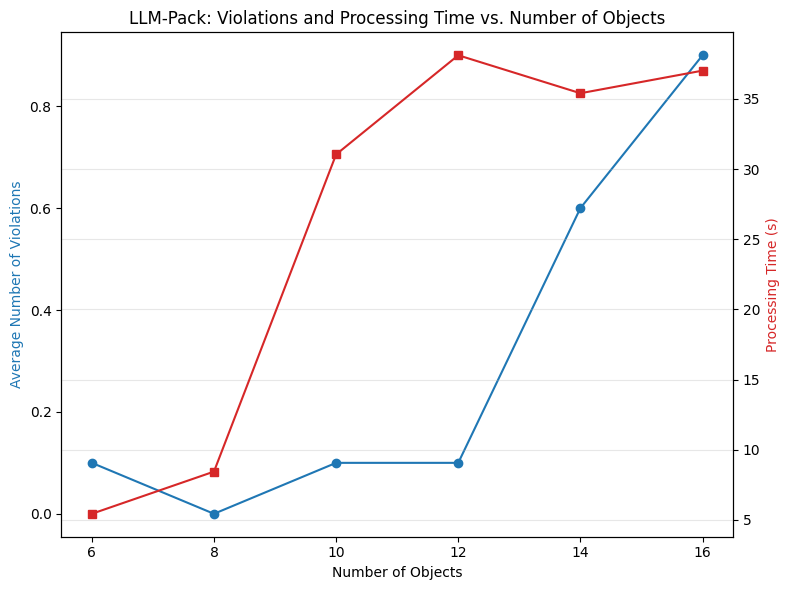

: 

: 

In [ ]:
# plot the results with dual y-axis (violations and processing time)
import matplotlib.pyplot as plt

scaling_table_vis = scaling_table.reset_index(inplace=False)
scaling_table_vis.rename(columns={"index": "num_objects"}, inplace=True)

# Ensure consistent ordering by number of objects
scaling_table_vis.sort_values("num_objects", inplace=True)

fig, ax1 = plt.subplots(figsize=(8, 6))

# Primary axis: average number of violations
ax1.plot(
    scaling_table_vis["num_objects"],
    scaling_table_vis["n_violations"],
    marker="o",
    color="tab:blue",
    label="Avg Violations",
)
ax1.set_xlabel("Number of Objects", color="black")
ax1.set_ylabel("Average Number of Violations", color="tab:blue")  # label matches curve color
ax1.tick_params(axis="x", labelcolor="black")
ax1.tick_params(axis="y", labelcolor="black")  # ticks remain black

# Secondary axis: processing time (always present)
ax2 = ax1.twinx()
ax2.plot(
    scaling_table_vis["num_objects"],
    scaling_table_vis["packing_time"],
    marker="s",
    color="tab:red",
    label="Processing Time (s)",
)
ax2.set_ylabel("Processing Time (s)", color="tab:red")  # label matches curve color
ax2.tick_params(axis="y", labelcolor="black")  # ticks remain black

# No legend per request
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("LLM-Pack: Violations and Processing Time vs. Number of Objects")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
exporter.export()

Writing output to /home/blei/BagBuddy/evaluation/c_evaluator/python_results.tex.
Exporting elements as LaTex functions. PGF files will be copied to the output directory.

Tables:
\tabbaseline
\tabablation
\tabsensitivityStudy


: 

: 

: 

: 